# Example: how to add a "perturbation"

## Perturbation with a function

Let’s consider the case of SU Cyg from Gallenne et al. 2025 (A&A, 693, A111 (2025), https://doi.org/10.1051/0004-6361/202452346). This system contains three stars: the Cepheid and a close subsystem B, with an estimated photocentric semi-major axis of 12 μas (Sivkova, in prep.). Although we can treat the subsystem as a single object, we will add its photocentric orbit as a perturbation to the second component.

In [34]:
from simbinary import SimBinary, fitGaia
import matplotlib.pyplot as plt
from functools import partial
import numpy as np

First, we simulate the system with only two companions, using the orbital parameters from Gallenne et al. 2025.

In [35]:
params_SUCyg = {'Object': 'SU Cyg',
 'type': 'cepheid',
 'P': 549.077,
 'a': 3.052,
 'e': 0.339,
 'i': 81.28,
 'Omega': 266.24,
 'w': 223.16,
 'T0': 2443765.94,
 'q': 1.08,
 'plx': 1.08,
 'Vcomp': 9.86
}

Gaia DR3 ID added with Simbad
RA/DEC coordinates added with Gaia DR3
Proper motion RA/DEC added with Gaia DR3
Gmag added with Gaia DR3
Applying correction for DR3 proper motion...
Correction: 0.071±0.047 -0.28±0.053
Proper motion corrected to: 0.036±0.091 and -2.967±0.11 mas


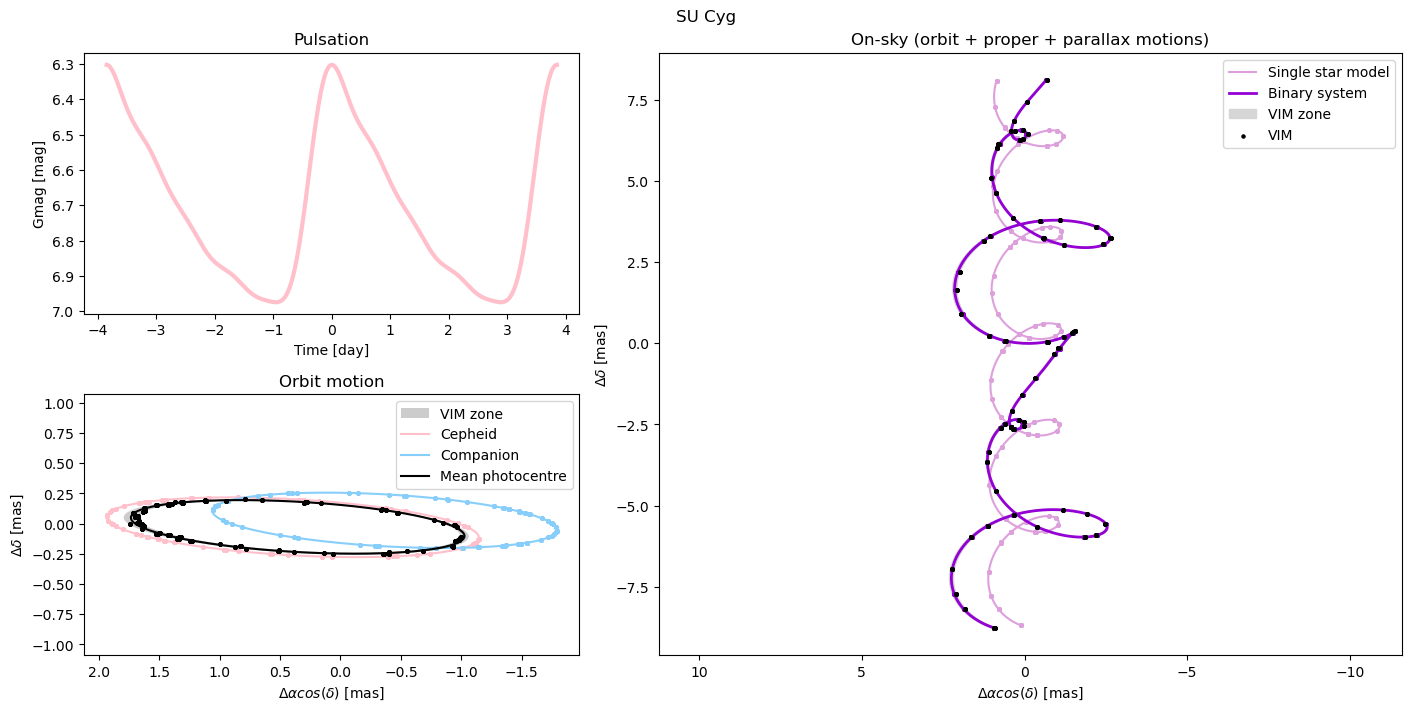

In [36]:
sb_SUCyg = SimBinary(params_SUCyg, DataRelease = 4)

axs = sb_SUCyg.PlotCepheid(Npoints=500)

additional_params = {
    'pmra': sb_SUCyg.ObjectPMRA,
    'pmdec': sb_SUCyg.ObjectPMDEC,
    'ra': sb_SUCyg.ObjectRA,
    'dec': sb_SUCyg.ObjectDEC,
    'id3': sb_SUCyg.id3,
    'Vtot': sb_SUCyg.ObjectGmag
}

params_SUCyg = params_SUCyg | additional_params # updating the parameters to avoid re-querying

Next, we consider the orbit of subsystem B. From the papers, we know it is a tight orbit with a period of 4.67 days. We assume a circular orbit.

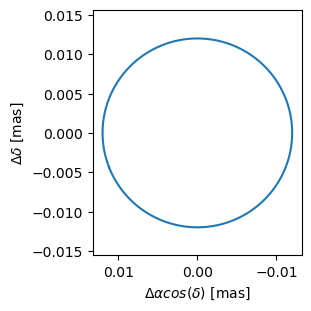

In [37]:
params_B = {
 'P': 4.67529,
 'a': 0.012,
 'e': 0,
 'i': 0,
 'Omega': 0,
 'w': 0,
 'T0': 2456977.994,
}

timesOrb = np.linspace(-params_B['P']/2, params_B['P']/2, 500)
ra, dec = sb_SUCyg.orbit(params_B, timesOrb)

# visualization of the subsystem's orbit
fig, ax = plt.subplots(1,1, figsize=(3, 3), constrained_layout=True)
ax.plot(ra, dec)
ax.set_xlabel(r'$\Delta \alpha cos(\delta)$ [mas]')
ax.set_ylabel(r'$\Delta \delta$ [mas]')
ax.xaxis.set_inverted(True)
ax.set_aspect('equal', adjustable='datalim')

We are now ready to “add” a third component. Let's consider the Cepheid as a non-pulsating star for this visualization, since the VIM effect would otherwise mix with the subsystem B contribution in the photocentric displacement.

Perturbation for component 2


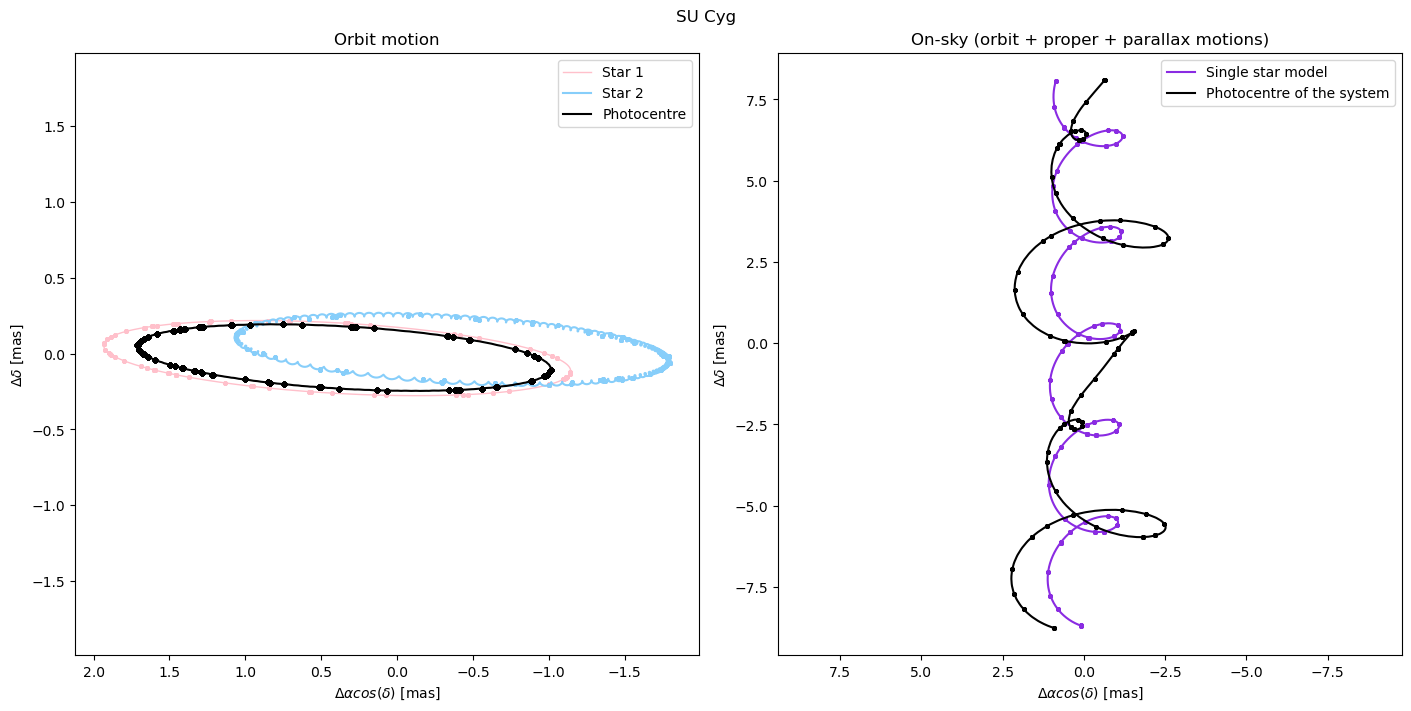

In [38]:
params_SUCyg['type'] = 'binary' # changing the type to a simple (non-pulsating) binary

# The perturbation must be passed as a dictionary containing a 'component' 1 or 2 and a 'value'
pert = {'component':2, 'value': partial(sb_SUCyg.orbit, params_B)}
# here we use a build-in orbit function, but it can be any custom function
# the custom function must take time array as input and provide perturbation's [ra, dec] as output

sb_withB = SimBinary(params_SUCyg, DataRelease = 4, perturbation = pert)

ax1, ax2 = sb_withB.Plot(Npoints=5000) # some extra points for visualization

In the plot, a small wobble is visible for Star 2, but not in the photocentre. There is indeed a contribution to the photocentre, however, since Star 2 (i.e. subsystem B) is much fainter than the primary star and its contribution is very small. Let’s zoom in on a section of the photocentric orbit.

Note that the continuous line does not exactly follow the Star 2 points. This is because the continuous line is generated for a single orbit for visualization purposes, while the points correspond to multiple orbital cycles, as the system’s period is shorter than the DR4 time span.

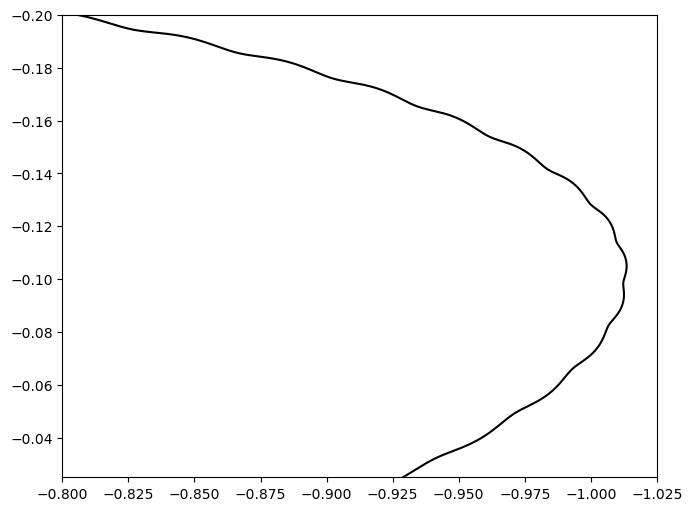

In [39]:
fig, ax = plt.subplots(1,1, figsize=(7, 5), constrained_layout=True)
# we copy only photocentric orbit to zoom
ax.plot(ax1.lines[2].get_xdata(), ax1.lines[2].get_ydata(), color=ax1.lines[2].get_color())
ax.set_aspect('equal', adjustable='box')
ax.set_xlim(-1.025, -0.8)
ax.set_ylim(-0.025, -0.20)
ax.xaxis.set_inverted(True)

A small wobble is present. We can now compare the cases with and without subsystem B.

Perturbation for component 2


Text(0, 0.5, 'Residuals, [mas]')

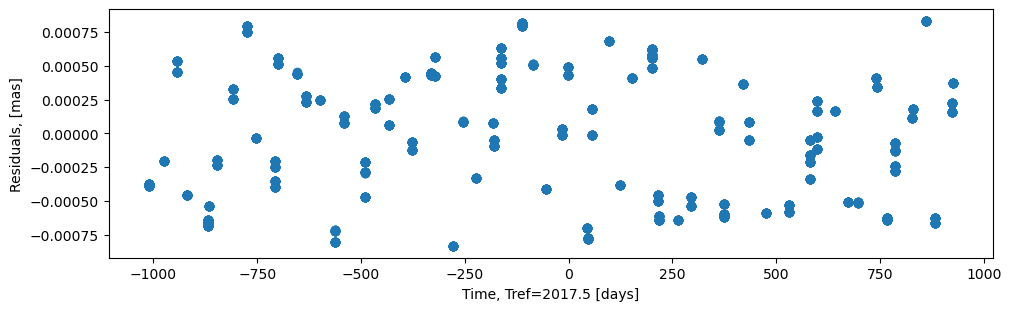

In [40]:
params_SUCyg['type'] = 'cepheid' # back to cepheid
# we redo the simulation with Cepheid now, to compare the two cases: approximated and not
sb_withB = SimBinary(params_SUCyg, DataRelease = 4, perturbation = pert)

residuals = sb_withB.w_bs - sb_SUCyg.w_bs

fig, ax = plt.subplots(1,1, figsize=(10, 3), constrained_layout=True)
ax.scatter(sb_SUCyg.reltimes, residuals)
ax.set_xlabel(f'Time, Tref={sb_SUCyg.Tref} [days]')
ax.set_ylabel('Residuals, [mas]')

The residuals are small, not exceeding the 0.75 μas level. Therefore, subsystem B can be approximated as a single object.

## Array perturbation
We have seen that a perturbation can be added using a partial function. It is also possible to use an array. In this case, each value in the array is associated with a measurement. Therefore, the array length must be at least equal to the number of per-CCD observations: DR3 length for DR3 simulations and earlier releases (or DR1/DR2 length if the proper motion correction is not needed, since the correction uses DR3), and DR4/DR5 length for DR4/DR5 simulations.

As an example, consider a flower-shaped array that we apply to component 1.

Perturbation for component 1
Perturbation for component 1


Text(0, 0.5, 'Residuals, [mas]')

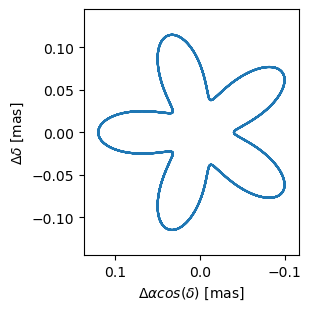

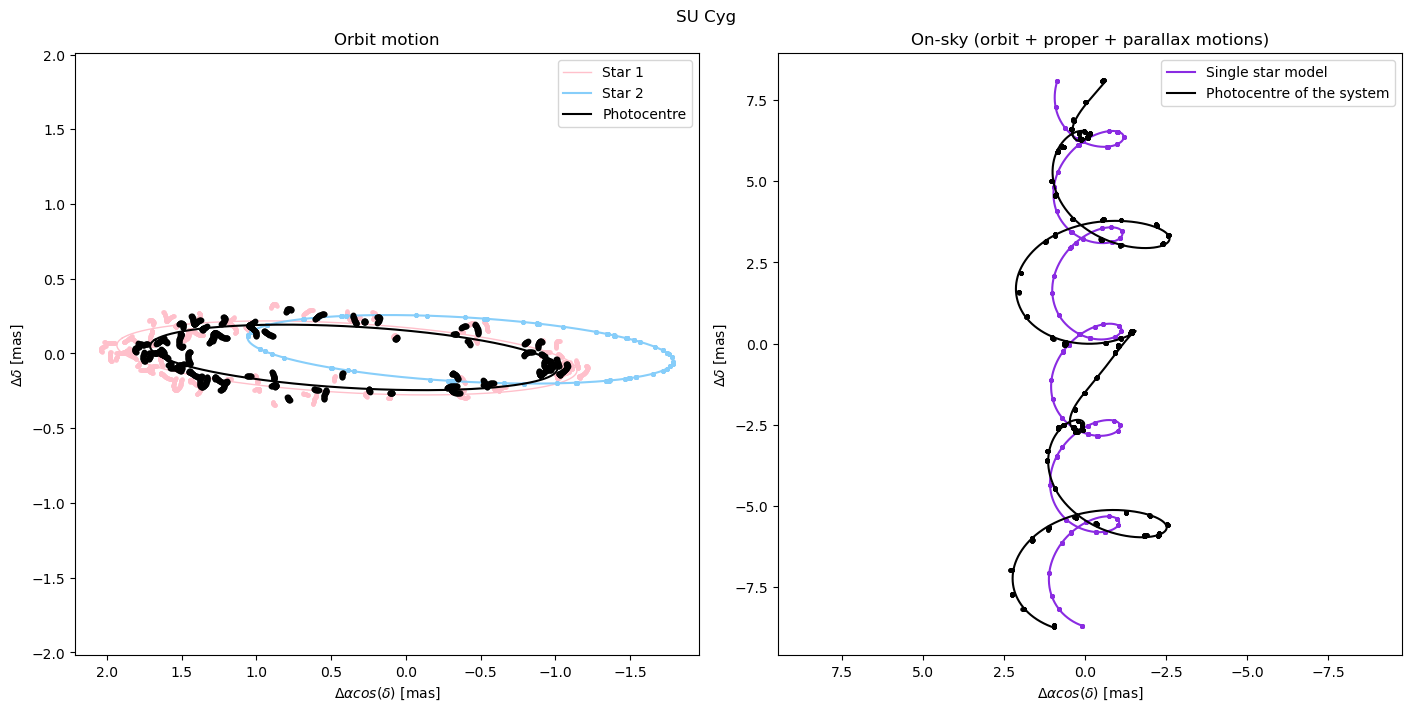

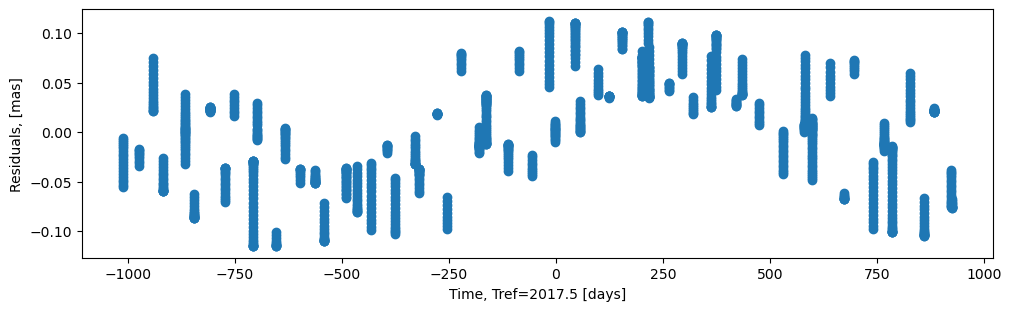

In [41]:
params_SUCyg['type'] = 'binary' # back to binary for to see better

# A random flower shape
theta = np.linspace(0, 5*2*np.pi, 1500)
A = 0.08
B = 0.04
n = 5
r = A + B * np.cos(n * theta)
x = r * np.cos(theta)
y = r * np.sin(theta)

fig, ax = plt.subplots(1,1, figsize=(3, 3), constrained_layout=True)
ax.plot(x, y)
ax.set_xlabel(r'$\Delta \alpha cos(\delta)$ [mas]')
ax.set_ylabel(r'$\Delta \delta$ [mas]')
ax.xaxis.set_inverted(True)
ax.set_aspect('equal', adjustable='datalim')

pert = {'component':1, 'value': (x, y)}
sb_withB = SimBinary(params_SUCyg, DataRelease = 4, perturbation = pert)
ax1, ax2 = sb_withB.Plot(Npoints=5000)

# let's compare flower and flowerless SU Cyg system
params_SUCyg['type'] = 'cepheid'

sb_withB = SimBinary(params_SUCyg, DataRelease = 4, perturbation = pert)

residuals = sb_withB.w_bs - sb_SUCyg.w_bs

fig, ax = plt.subplots(1,1, figsize=(10, 3), constrained_layout=True)
ax.scatter(sb_SUCyg.reltimes, residuals)
ax.set_xlabel(f'Time, Tref={sb_SUCyg.Tref} [days]')
ax.set_ylabel('Residuals, [mas]')